# Bangkok Multi-Horizon Rain Models

Train separate models to predict whether it will rain at each future horizon for every Bangkok grid point:

- `rain_next_1h`
- `rain_next_2h`
- `rain_next_3h`
- `rain_next_6h`

Each target is based on exact future hourly precipitation using `LEAD(precipitation, horizon)` from PostgreSQL table `"OM_BKK_DATA"`.

## 1. Setup

In [1]:
# Optional: uncomment if needed.
# %pip install pandas psycopg2-binary scikit-learn lightgbm joblib matplotlib seaborn numpy

In [2]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

In [3]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_BKK_DATA"'
MODEL_DIR = Path("../ML_Model_V2/trained_models/om_bkk_multi_horizon")

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None  # Example for quick runs: 300_000
RANDOM_STATE = 42

## 3. Load Multi-Horizon Features

Feature windows use current and past data only. Future columns are targets only.

In [4]:
FEATURE_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "surface_pressure",
    "dew_point_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "temperature_dew_point_spread",
    "pressure_msl_change_3h",
    "pressure_msl_change_6h",
    "precipitation_lag_1h",
    "precipitation_lag_2h",
    "precipitation_lag_3h",
    "precipitation_lag_6h",
    "precipitation_sum_past_3h",
    "precipitation_sum_past_6h",
    "precipitation_sum_past_12h",
    "precipitation_sum_past_24h",
    "cloud_cover_lag_1h",
    "cloud_cover_lag_3h",
    "cloud_cover_lag_6h",
    "humidity_lag_1h",
    "humidity_lag_3h",
    "humidity_lag_6h",
    "wind_speed_lag_1h",
    "wind_speed_lag_3h",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "grid_row",
    "grid_column",
    "latitude",
    "longitude",
]

TARGET_COLUMNS = [f"rain_next_{horizon}h" for horizon in HORIZONS]
FUTURE_PRECIP_COLUMNS = [f"precipitation_next_{horizon}h" for horizon in HORIZONS]

def connect():
    return psycopg2.connect(**DB_CONFIG)

def future_precip_sql():
    return ",\n            ".join(
        f"LEAD(precipitation, {horizon}) OVER w AS precipitation_next_{horizon}h"
        for horizon in HORIZONS
    )

def read_training_data(sample_rows=None):
    query = f'''
    WITH features AS (
        SELECT
            grid_number,
            grid_row,
            grid_column,
            latitude,
            longitude,
            local_forecast_time AS forecast_time,
            temperature_2m,
            relative_humidity_2m,
            pressure_msl,
            surface_pressure,
            dew_point_2m,
            precipitation,
            cloud_cover,
            wind_speed_10m,
            wind_direction_10m,
            temperature_2m - dew_point_2m AS temperature_dew_point_spread,
            pressure_msl - LAG(pressure_msl, 3) OVER w AS pressure_msl_change_3h,
            pressure_msl - LAG(pressure_msl, 6) OVER w AS pressure_msl_change_6h,
            LAG(precipitation, 1) OVER w AS precipitation_lag_1h,
            LAG(precipitation, 2) OVER w AS precipitation_lag_2h,
            LAG(precipitation, 3) OVER w AS precipitation_lag_3h,
            LAG(precipitation, 6) OVER w AS precipitation_lag_6h,
            SUM(precipitation) OVER (
                PARTITION BY grid_number ORDER BY local_forecast_time
                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
            ) AS precipitation_sum_past_3h,
            SUM(precipitation) OVER (
                PARTITION BY grid_number ORDER BY local_forecast_time
                ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
            ) AS precipitation_sum_past_6h,
            SUM(precipitation) OVER (
                PARTITION BY grid_number ORDER BY local_forecast_time
                ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
            ) AS precipitation_sum_past_12h,
            SUM(precipitation) OVER (
                PARTITION BY grid_number ORDER BY local_forecast_time
                ROWS BETWEEN 23 PRECEDING AND CURRENT ROW
            ) AS precipitation_sum_past_24h,
            LAG(cloud_cover, 1) OVER w AS cloud_cover_lag_1h,
            LAG(cloud_cover, 3) OVER w AS cloud_cover_lag_3h,
            LAG(cloud_cover, 6) OVER w AS cloud_cover_lag_6h,
            LAG(relative_humidity_2m, 1) OVER w AS humidity_lag_1h,
            LAG(relative_humidity_2m, 3) OVER w AS humidity_lag_3h,
            LAG(relative_humidity_2m, 6) OVER w AS humidity_lag_6h,
            LAG(wind_speed_10m, 1) OVER w AS wind_speed_lag_1h,
            LAG(wind_speed_10m, 3) OVER w AS wind_speed_lag_3h,
            {future_precip_sql()},
            SIN(2 * pi() * EXTRACT(HOUR FROM local_forecast_time) / 24.0) AS hour_sin,
            COS(2 * pi() * EXTRACT(HOUR FROM local_forecast_time) / 24.0) AS hour_cos,
            SIN(2 * pi() * EXTRACT(MONTH FROM local_forecast_time) / 12.0) AS month_sin,
            COS(2 * pi() * EXTRACT(MONTH FROM local_forecast_time) / 12.0) AS month_cos
        FROM {TABLE_NAME}
        WINDOW w AS (PARTITION BY grid_number ORDER BY local_forecast_time)
    )
    SELECT *
    FROM features
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND precipitation_next_6h IS NOT NULL
    ORDER BY forecast_time, grid_number
    '''
    if sample_rows:
        query = f'''
        SELECT *
        FROM ({query}) complete_rows
        ORDER BY random()
        LIMIT {int(sample_rows)}
        '''
    with connect() as conn:
        return pd.read_sql_query(query, conn, parse_dates=["forecast_time"])

df = read_training_data(SAMPLE_ROWS)
for horizon in HORIZONS:
    df[f"rain_next_{horizon}h"] = (df[f"precipitation_next_{horizon}h"] >= RAIN_THRESHOLD_MM).astype("int8")

print(f"Rows loaded: {len(df):,}")
print(f"Time range: {df['forecast_time'].min()} to {df['forecast_time'].max()}")
df[["forecast_time", "grid_number", *FUTURE_PRECIP_COLUMNS, *TARGET_COLUMNS]].head()

C:\Users\Brandon\AppData\Local\Temp\ipykernel_20176\2387966181.py:129: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn, parse_dates=["forecast_time"])


Rows loaded: 2,453,472
Time range: 2021-07-20 06:00:00 to 2026-07-19 17:00:00


,forecast_time,grid_number,precipitation_next_1h,precipitation_next_2h,precipitation_next_3h,precipitation_next_6h,rain_next_1h,rain_next_2h,rain_next_3h,rain_next_6h
0,2021-07-20 06:00:00,1,1.2000,0.7000,0.2000,0.1000,1,1,1,1
1,2021-07-20 06:00:00,2,1.1000,0.7000,0.1000,0.0000,1,1,1,0
2,2021-07-20 06:00:00,3,1.1000,0.7000,0.1000,0.0000,1,1,1,0
3,2021-07-20 06:00:00,4,1.0000,0.8000,0.1000,0.1000,1,1,1,1
4,2021-07-20 06:00:00,5,1.0000,0.8000,0.1000,0.1000,1,1,1,1


## 4. Target Balance By Horizon

,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_next_1h,0.1000,2453472,541118,0.2206
1,2,rain_next_2h,0.1000,2453472,541062,0.2205
2,3,rain_next_3h,0.1000,2453472,541013,0.2205
3,6,rain_next_6h,0.1000,2453472,540946,0.2205


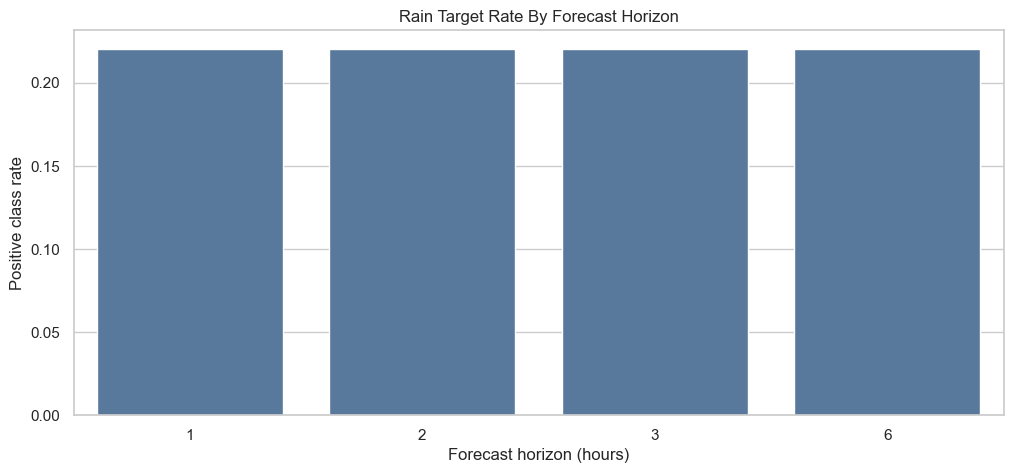

In [5]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": len(df),
        "rain_rows": int(df[f"rain_next_{horizon}h"].sum()),
        "rain_rate": float(df[f"rain_next_{horizon}h"].mean()),
    }
    for horizon in HORIZONS
])
display(target_balance)

sns.barplot(data=target_balance, x="horizon_h", y="rain_rate", color="#4c78a8")
plt.title("Rain Target Rate By Forecast Horizon")
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Positive class rate")
plt.show()

## 5. Chronological Split

In [6]:
def add_time_split(data, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.array(sorted(data["forecast_time"].unique()))
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    out = data.copy()
    out["split"] = "test"
    out.loc[out["forecast_time"] < train_end, "split"] = "train"
    out.loc[(out["forecast_time"] >= train_end) & (out["forecast_time"] < validation_end), "split"] = "validation"
    return out, train_end, validation_end

model_df, train_end, validation_end = add_time_split(df, TRAIN_FRACTION, VALIDATION_FRACTION)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")
display(model_df.groupby("split").size().rename("rows").reset_index())

train_df = model_df[model_df["split"] == "train"]
validation_df = model_df[model_df["split"] == "validation"]
test_df = model_df[model_df["split"] == "test"]

x_train = train_df[FEATURE_COLUMNS].astype("float32")
x_validation = validation_df[FEATURE_COLUMNS].astype("float32")
x_test = test_df[FEATURE_COLUMNS].astype("float32")

Train before: 2025-01-18 02:00:00
Validation before: 2025-10-18 22:00:00


,split,rows
0,test,368032
1,train,1717408
2,validation,368032


## 6. Evaluation Helpers

In [7]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)

def evaluate_probabilities(y_true, probabilities, model_name, horizon, split):
    base = {
        "model": model_name,
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df

def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(["model", "horizon_h", "split", "f1"], ascending=[True, True, True, False])
        .groupby(["model", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "horizon_h", "split"])
    )

## 7. Train HistGradientBoosting Models

In [8]:
hist_models = {}
hist_metric_rows = []
hist_threshold_tables = []

for horizon in HORIZONS:
    target = f"rain_next_{horizon}h"
    print(f"Training HistGradientBoosting for {target}...")
    y_train = train_df[target].astype("int8")
    y_validation = validation_df[target].astype("int8")
    y_test = test_df[target].astype("int8")

    model = HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=250,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
    )
    model.fit(x_train, y_train)
    hist_models[horizon] = model

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(
            y_split.to_numpy(), probabilities, "hist_gradient_boosting", horizon, split_name
        )
        hist_metric_rows.append(metrics)
        hist_threshold_tables.append(thresholds)

hist_metrics = pd.DataFrame(hist_metric_rows)
hist_threshold_results = pd.concat(hist_threshold_tables, ignore_index=True)

display(hist_metrics)
display(best_thresholds(hist_threshold_results))

Training HistGradientBoosting for rain_next_1h...
Training HistGradientBoosting for rain_next_2h...
Training HistGradientBoosting for rain_next_3h...
Training HistGradientBoosting for rain_next_6h...


,model,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
0,hist_gradient_boosting,1,validation,368032,0.2684,0.8967,0.7805,0.1092
1,hist_gradient_boosting,1,test,368032,0.1625,0.9162,0.7213,0.0770
2,hist_gradient_boosting,2,validation,368032,0.2685,0.8448,0.6625,0.1365
3,hist_gradient_boosting,2,test,368032,0.1624,0.8705,0.5674,0.0975
4,hist_gradient_boosting,3,validation,368032,0.2686,0.8188,0.6072,0.1472
5,hist_gradient_boosting,3,test,368032,0.1624,0.8518,0.5092,0.1038
6,hist_gradient_boosting,6,validation,368032,0.2689,0.7856,0.5452,0.1587
7,hist_gradient_boosting,6,test,368032,0.1622,0.8296,0.4521,0.1097


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
21,0.3000,0.1663,0.8896,0.6568,0.6721,0.6643,287200,21009,19618,40205,hist_gradient_boosting,1,test,368032,0.1625,0.9162,0.7213,0.0770
5,0.3500,0.2915,0.8402,0.6864,0.7454,0.7147,235601,33647,25150,73634,hist_gradient_boosting,1,validation,368032,0.2684,0.8967,0.7805,0.1092
53,0.2000,0.2408,0.8234,0.4707,0.6976,0.5621,261350,46901,18076,41705,hist_gradient_boosting,2,test,368032,0.1624,0.8705,0.5674,0.0975
38,0.3000,0.3511,0.7731,0.5593,0.7313,0.6339,212260,56946,26552,72274,hist_gradient_boosting,2,validation,368032,0.2685,0.8448,0.6625,0.1365
87,0.2000,0.2453,0.8084,0.4403,0.6651,0.5299,257752,50521,20012,39747,hist_gradient_boosting,3,test,368032,0.1624,0.8518,0.5092,0.1038
71,0.2500,0.4115,0.7296,0.4978,0.7627,0.6024,193118,76059,23454,75401,hist_gradient_boosting,3,validation,368032,0.2686,0.8188,0.6072,0.1472
121,0.2000,0.2513,0.7924,0.4097,0.6348,0.4980,253746,54597,21798,37891,hist_gradient_boosting,6,test,368032,0.1622,0.8296,0.4521,0.1097
105,0.2500,0.4367,0.6946,0.4582,0.7443,0.5672,182000,87078,25301,73653,hist_gradient_boosting,6,validation,368032,0.2689,0.7856,0.5452,0.1587


## 8. Train LightGBM Models

In [9]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

lgbm_models = {}
lgbm_metric_rows = []
lgbm_threshold_tables = []

for horizon in HORIZONS:
    target = f"rain_next_{horizon}h"
    print(f"Training LightGBM for {target}...")
    y_train = train_df[target].astype("int8")
    y_validation = validation_df[target].astype("int8")
    y_test = test_df[target].astype("int8")
    scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

    model = LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.04,
        num_leaves=63,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_validation, y_validation)],
        eval_metric="binary_logloss",
    )
    lgbm_models[horizon] = model

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(
            y_split.to_numpy(), probabilities, "lightgbm", horizon, split_name
        )
        lgbm_metric_rows.append(metrics)
        lgbm_threshold_tables.append(thresholds)

lgbm_metrics = pd.DataFrame(lgbm_metric_rows)
lgbm_threshold_results = pd.concat(lgbm_threshold_tables, ignore_index=True)

display(lgbm_metrics)
display(best_thresholds(lgbm_threshold_results))

Training LightGBM for rain_next_1h...
[LightGBM] [Info] Number of positive: 382511, number of negative: 1334897
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.150985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4949
[LightGBM] [Info] Number of data points in the train set: 1717408, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222726 -> initscore=-1.249852
[LightGBM] [Info] Start training from score -1.249852
Training LightGBM for rain_next_2h...
[LightGBM] [Info] Number of positive: 382455, number of negative: 1334953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.184816 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4949
[LightGBM] [Info] Number of

,model,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
0,lightgbm,1,validation,368032,0.2684,0.8981,0.7815,0.1349
1,lightgbm,1,test,368032,0.1625,0.9172,0.7223,0.0878
2,lightgbm,2,validation,368032,0.2685,0.8456,0.6630,0.1705
3,lightgbm,2,test,368032,0.1624,0.8706,0.5636,0.1117
4,lightgbm,3,validation,368032,0.2686,0.8186,0.6069,0.1848
5,lightgbm,3,test,368032,0.1624,0.8503,0.5053,0.1200
6,lightgbm,6,validation,368032,0.2689,0.7863,0.5470,0.2010
7,lightgbm,6,test,368032,0.1622,0.8264,0.4482,0.1286


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
27,0.6000,0.1630,0.8905,0.6628,0.6646,0.6637,287980,20229,20064,39759,lightgbm,1,test,368032,0.1625,0.9172,0.7223,0.0878
11,0.6500,0.2906,0.8414,0.6890,0.7458,0.7163,235987,33261,25108,73676,lightgbm,1,validation,368032,0.2684,0.8981,0.7815,0.1349
58,0.4500,0.2403,0.8230,0.4697,0.6950,0.5606,261351,46900,18233,41548,lightgbm,2,test,368032,0.1624,0.8706,0.5636,0.1117
43,0.5500,0.3795,0.7622,0.5405,0.7639,0.6331,205034,64172,23330,75496,lightgbm,2,validation,368032,0.2685,0.8456,0.6630,0.1705
92,0.4500,0.2483,0.8058,0.4359,0.6666,0.5271,256730,51543,19923,39836,lightgbm,3,test,368032,0.1624,0.8503,0.5053,0.1200
77,0.5500,0.3926,0.7374,0.5077,0.7421,0.6029,198038,71139,25494,73361,lightgbm,3,validation,368032,0.2686,0.8186,0.6069,0.1848
125,0.4000,0.2888,0.7699,0.3823,0.6807,0.4897,242703,65640,19056,40633,lightgbm,6,test,368032,0.1622,0.8264,0.4482,0.1286
110,0.5000,0.4618,0.6831,0.4480,0.7694,0.5662,175263,93815,22822,76132,lightgbm,6,validation,368032,0.2689,0.7863,0.5470,0.2010


## 9. Compare Horizons And Models

,model,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,hist_gradient_boosting,1,test,368032,0.1625,0.9162,0.7213,0.0770
0,hist_gradient_boosting,1,validation,368032,0.2684,0.8967,0.7805,0.1092
9,lightgbm,1,test,368032,0.1625,0.9172,0.7223,0.0878
8,lightgbm,1,validation,368032,0.2684,0.8981,0.7815,0.1349
3,hist_gradient_boosting,2,test,368032,0.1624,0.8705,0.5674,0.0975
2,hist_gradient_boosting,2,validation,368032,0.2685,0.8448,0.6625,0.1365
11,lightgbm,2,test,368032,0.1624,0.8706,0.5636,0.1117
10,lightgbm,2,validation,368032,0.2685,0.8456,0.6630,0.1705
5,hist_gradient_boosting,3,test,368032,0.1624,0.8518,0.5092,0.1038
4,hist_gradient_boosting,3,validation,368032,0.2686,0.8188,0.6072,0.1472


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
21,0.3000,0.1663,0.8896,0.6568,0.6721,0.6643,287200,21009,19618,40205,hist_gradient_boosting,1,test,368032,0.1625,0.9162,0.7213,0.0770
163,0.6000,0.1630,0.8905,0.6628,0.6646,0.6637,287980,20229,20064,39759,lightgbm,1,test,368032,0.1625,0.9172,0.7223,0.0878
53,0.2000,0.2408,0.8234,0.4707,0.6976,0.5621,261350,46901,18076,41705,hist_gradient_boosting,2,test,368032,0.1624,0.8705,0.5674,0.0975
194,0.4500,0.2403,0.8230,0.4697,0.6950,0.5606,261351,46900,18233,41548,lightgbm,2,test,368032,0.1624,0.8706,0.5636,0.1117
87,0.2000,0.2453,0.8084,0.4403,0.6651,0.5299,257752,50521,20012,39747,hist_gradient_boosting,3,test,368032,0.1624,0.8518,0.5092,0.1038
228,0.4500,0.2483,0.8058,0.4359,0.6666,0.5271,256730,51543,19923,39836,lightgbm,3,test,368032,0.1624,0.8503,0.5053,0.1200
121,0.2000,0.2513,0.7924,0.4097,0.6348,0.4980,253746,54597,21798,37891,hist_gradient_boosting,6,test,368032,0.1622,0.8296,0.4521,0.1097
261,0.4000,0.2888,0.7699,0.3823,0.6807,0.4897,242703,65640,19056,40633,lightgbm,6,test,368032,0.1622,0.8264,0.4482,0.1286


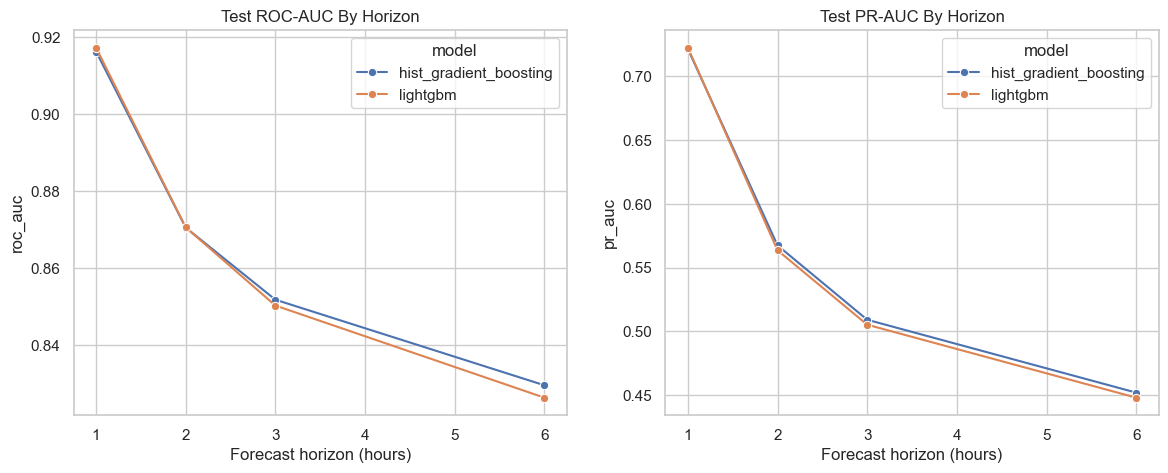

In [10]:
all_metrics = pd.concat([hist_metrics, lgbm_metrics], ignore_index=True)
all_threshold_results = pd.concat([hist_threshold_results, lgbm_threshold_results], ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)

display(all_metrics.sort_values(["horizon_h", "model", "split"]))
display(best_by_f1[best_by_f1["split"] == "test"].sort_values(["horizon_h", "model"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="roc_auc", hue="model", marker="o", ax=axes[0])
axes[0].set_title("Test ROC-AUC By Horizon")
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="pr_auc", hue="model", marker="o", ax=axes[1])
axes[1].set_title("Test PR-AUC By Horizon")
for ax in axes:
    ax.set_xlabel("Forecast horizon (hours)")
plt.show()

## 10. LightGBM Feature Importance By Horizon

,horizon_h,feature,importance
2,1,pressure_msl,2640
11,1,pressure_msl_change_6h,1995
8,1,wind_direction_10m,1962
10,1,pressure_msl_change_3h,1757
4,1,dew_point_2m,1679
0,1,temperature_2m,1618
30,1,month_sin,1383
28,1,hour_sin,1359
29,1,hour_cos,1289
7,1,wind_speed_10m,1144


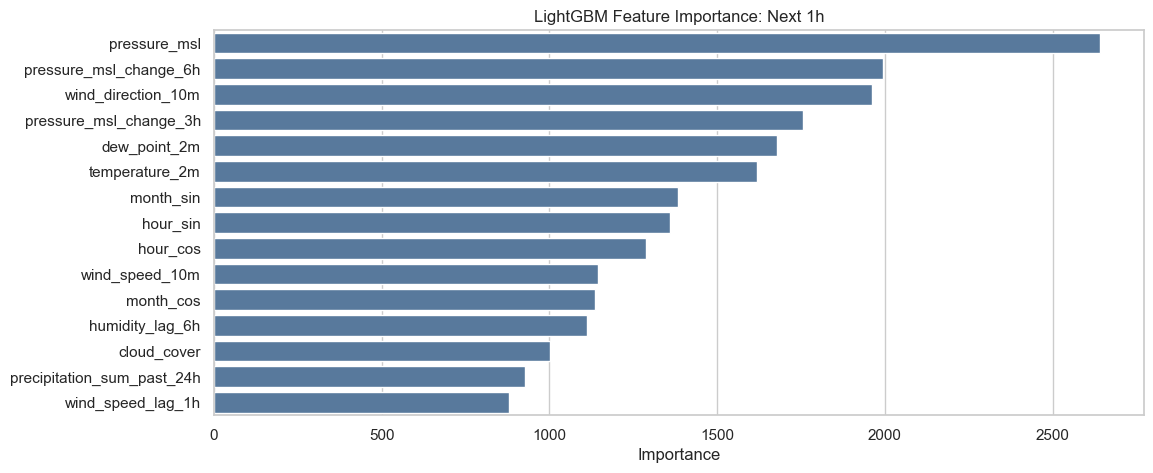

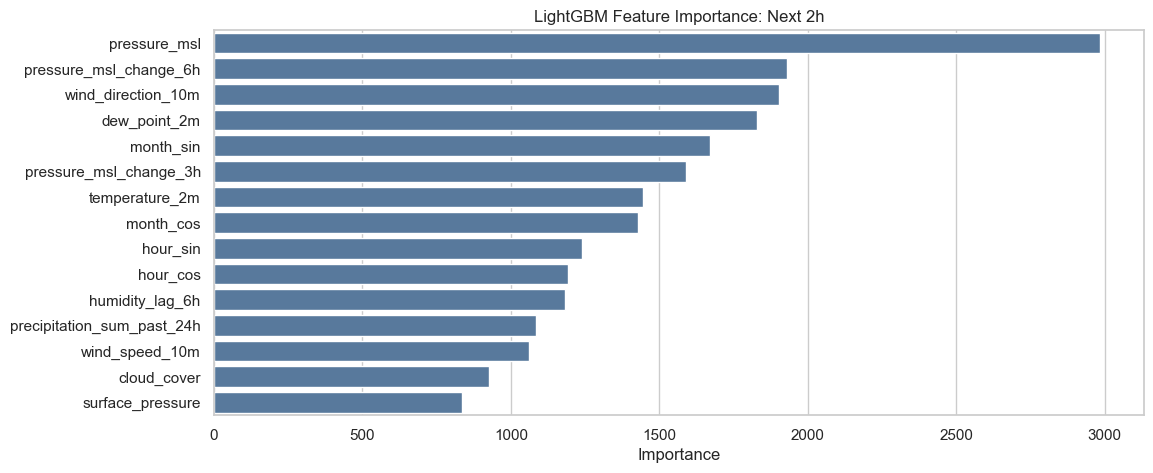

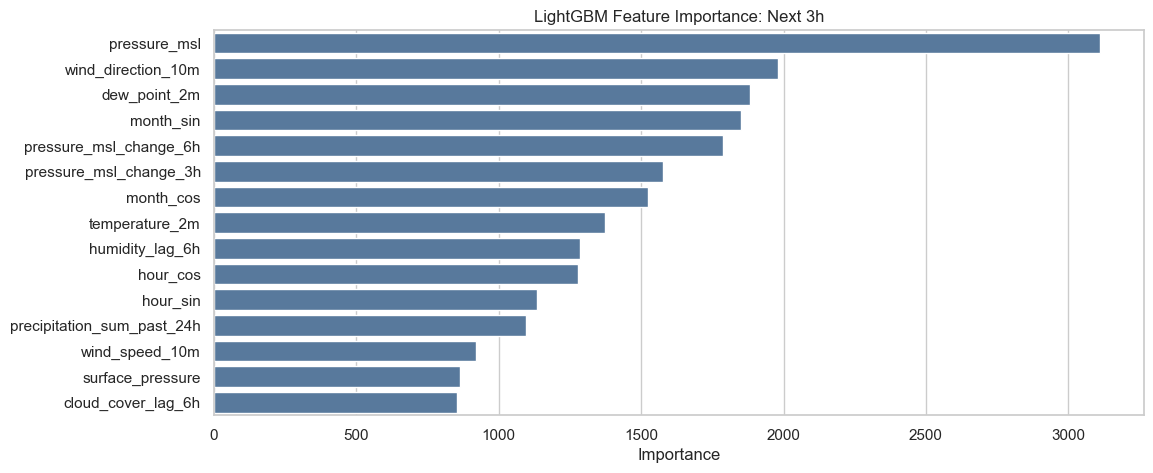

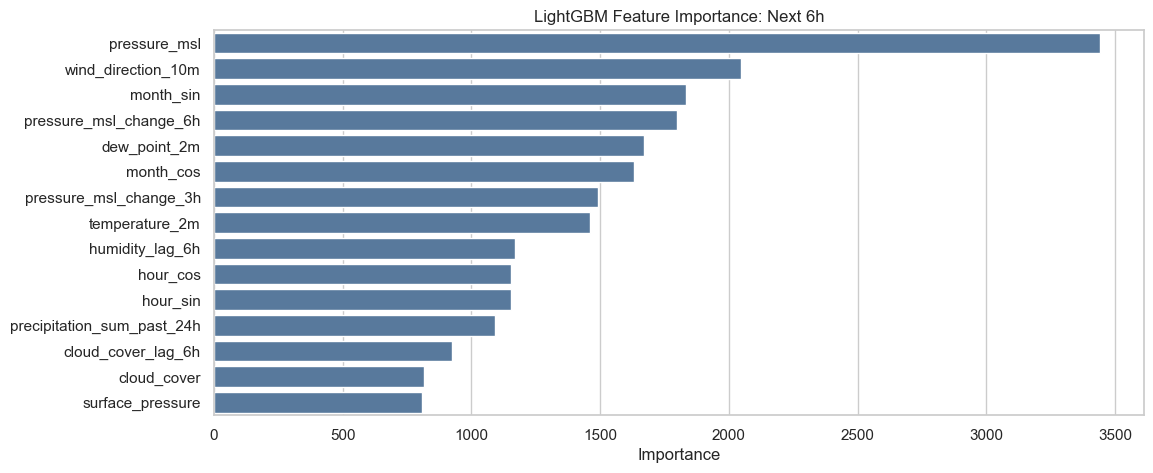

In [11]:
importance_rows = []
for horizon, model in lgbm_models.items():
    for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_):
        importance_rows.append({
            "horizon_h": horizon,
            "feature": feature,
            "importance": importance,
        })

importance = pd.DataFrame(importance_rows)
display(importance.sort_values(["horizon_h", "importance"], ascending=[True, False]).groupby("horizon_h").head(15))

for horizon in HORIZONS:
    top = importance[importance["horizon_h"] == horizon].sort_values("importance", ascending=False).head(15)
    sns.barplot(data=top, y="feature", x="importance", color="#4c78a8")
    plt.title(f"LightGBM Feature Importance: Next {horizon}h")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.show()

## 11. Save Models And Results

In [12]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in hist_models.items():
    path = MODEL_DIR / f"om_bkk_rain_next_{horizon}h_histgbm_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    joblib.dump(model, path)

for horizon, model in lgbm_models.items():
    path = MODEL_DIR / f"om_bkk_rain_next_{horizon}h_lightgbm_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    joblib.dump(model, path)

all_metrics.to_csv(MODEL_DIR / "multi_horizon_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "multi_horizon_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "multi_horizon_best_thresholds_by_f1.csv", index=False)
importance.to_csv(MODEL_DIR / "lightgbm_feature_importance_by_horizon.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_columns": FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "sample_rows": SAMPLE_ROWS,
    "model_dir": str(MODEL_DIR),
    "metrics": all_metrics.to_dict(orient="records"),
    "best_thresholds_by_f1": best_by_f1.to_dict(orient="records"),
}
(MODEL_DIR / "multi_horizon_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved models and result CSVs to {MODEL_DIR}")

Saved models and result CSVs to ..\ML_Model_V2\trained_models\om_bkk_multi_horizon
